<a href="https://colab.research.google.com/github/Sumit-koik/Financial-Advisor-Expense-Manager-AI-Agent-Development-Project-Dual-Track-Version/blob/main/Copy_of_Untitled9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pytesseract pillow pandas matplotlib transformers accelerate

In [ ]:
!apt-get install tesseract-ocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.


In [ ]:
import pytesseract
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving payment.png.jpeg to payment.png.jpeg


In [ ]:
image = Image.open("payment.png.jpeg")

text = pytesseract.image_to_string(image)

print(text)

BoM lei ee are.)

7 slo BYR

Util
© Completed

22 Feb 2026, 10:15pm

ty Mui cune er

LU Rec latt taco)
raat tte Ol)

To: Dominospizza

jubilantfoodworkslimi.payu@mairtel

From: ADITYA ABHAYKUMAR DANOLE (HDFC
Bank)
Google Pay + adityadanole141-1@okaxis

Google transaction ID
CICAgJi9INUKWA

oy

 

fea



In [ ]:
print(text)

BoM lei ee are.)

7 slo BYR

Util
© Completed

22 Feb 2026, 10:15pm

ty Mui cune er

LU Rec latt taco)
raat tte Ol)

To: Dominospizza

jubilantfoodworkslimi.payu@mairtel

From: ADITYA ABHAYKUMAR DANOLE (HDFC
Bank)
Google Pay + adityadanole141-1@okaxis

Google transaction ID
CICAgJi9INUKWA

oy

 

fea



In [ ]:
expense_data = []

expense_data.append({
    "text": text
})

print(expense_data)

[{'text': 'BoM lei ee are.)\n\n7 slo BYR\n\nUtil\n© Completed\n\n22 Feb 2026, 10:15pm\n\nty Mui cune er\n\nLU Rec latt taco)\nraat tte Ol)\n\nTo: Dominospizza\n\njubilantfoodworkslimi.payu@mairtel\n\nFrom: ADITYA ABHAYKUMAR DANOLE (HDFC\nBank)\nGoogle Pay + adityadanole141-1@okaxis\n\nGoogle transaction ID\nCICAgJi9INUKWA\n\noy\n\n \n\nfea\n\x0c'}]


In [ ]:
def categorize_expense(text):

    text = text.lower()

    if "dominospizza" in text or "zomato" in text:
        return "Food"

    elif "uber" in text or "ola" in text:
        return "Transport"

    elif "amazon" in text or "flipkart" in text:
        return "Shopping"

    elif "netflix" in text:
        return "Entertainment"

    else:
        return "Other"

In [ ]:
category = categorize_expense(text)

print("Expense Category:", category)

Expense Category: Food


In [ ]:
def financial_advice(category):

    if category == "Food":
        return "Try cooking at home more often to reduce spending."

    elif category == "Transport":
        return "Consider using public transport to save money."

    elif category == "Shopping":
        return "Avoid unnecessary online shopping."

    elif category == "Entertainment":
        return "Limit entertainment expenses to a fixed budget."

    else:
        return "Track your spending regularly."

In [ ]:
advice = financial_advice(category)

print("Advice:", advice)

Advice: Try cooking at home more often to reduce spending.


In [ ]:
df = pd.DataFrame([
    {"Expense Text": text,
     "Category": category,
     "Advice": advice}
])

print(df)

                                        Expense Text Category  \
0  BoM lei ee are.)\n\n7 slo BYR\n\nUtil\n© Compl...     Food   

                                              Advice  
0  Try cooking at home more often to reduce spend...  


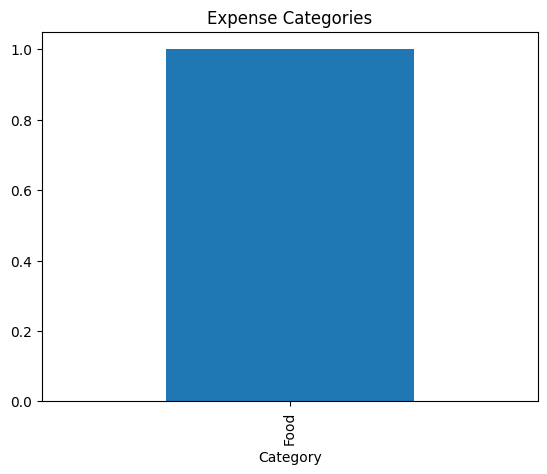

In [ ]:
df["Category"].value_counts().plot(kind="bar")

plt.title("Expense Categories")
plt.show()

# Week 3 – Expense Management System

In [ ]:
import json
import os
from datetime import datetime

In [ ]:
FILE_NAME = "expenses.json"

if not os.path.exists(FILE_NAME):
    with open(FILE_NAME, "w") as f:
        json.dump([], f)

print("Expense database ready")

Expense database ready


In [ ]:
def load_expenses():

    with open(FILE_NAME, "r") as f:
        return json.load(f)

In [ ]:
def save_expenses(expenses):

    with open(FILE_NAME, "w") as f:
        json.dump(expenses, f, indent=4)

In [ ]:
import re

def extract_amount(text):

    numbers = re.findall(r'\d+', text)

    if numbers:
        return int(numbers[0])
    else:
        return 0

In [ ]:
amount = extract_amount(text)

expense_record = {
    "amount": amount,
    "category": category,
    "description": text,
    "date": datetime.now().strftime("%Y-%m-%d")
}

print(expense_record)

{'amount': 7, 'category': 'Food', 'description': 'BoM lei ee are.)\n\n7 slo BYR\n\nUtil\n© Completed\n\n22 Feb 2026, 10:15pm\n\nty Mui cune er\n\nLU Rec latt taco)\nraat tte Ol)\n\nTo: Dominospizza\n\njubilantfoodworkslimi.payu@mairtel\n\nFrom: ADITYA ABHAYKUMAR DANOLE (HDFC\nBank)\nGoogle Pay + adityadanole141-1@okaxis\n\nGoogle transaction ID\nCICAgJi9INUKWA\n\noy\n\n \n\nfea\n\x0c', 'date': '2026-03-22'}


In [ ]:
expenses = load_expenses()

expenses.append(expense_record)

save_expenses(expenses)

print("Expense stored successfully")

Expense stored successfully


In [ ]:
data = load_expenses()

df = pd.DataFrame(data)

df

,amount,category,description,date
0,7,Food,BoM lei ee are.)\n\n7 slo BYR\n\nUtil\n© Compl...,2026-03-22


In [ ]:
total_spending = df["amount"].sum()

print("Total Spending:", total_spending)

Total Spending: 7


In [ ]:
category_summary = df.groupby("category")["amount"].sum()

print(category_summary)

category
Food    7
Name: amount, dtype: int64


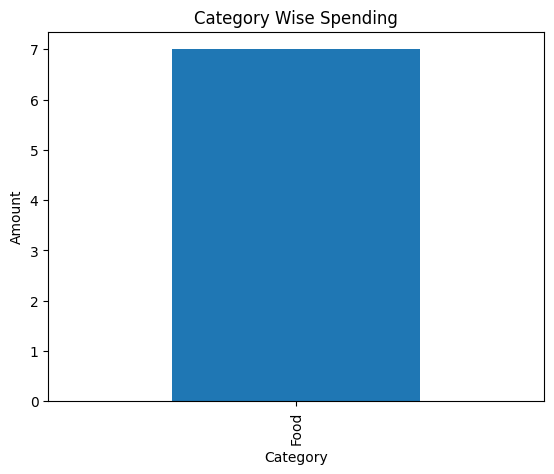

In [ ]:
category_summary.plot(kind="bar")

plt.title("Category Wise Spending")

plt.xlabel("Category")

plt.ylabel("Amount")

plt.show()

In [ ]:
def expense_agent():

    while True:

        print("\nExpense Manager Agent")

        print("1 Add Manual Expense")
        print("2 View Total Spending")
        print("3 View Category Summary")
        print("4 Exit")

        choice = input("Enter choice: ")

        if choice == "1":

            amount = float(input("Amount: "))
            desc = input("Description: ")

            cat = categorize_expense(desc)

            expense = {
                "amount": amount,
                "category": cat,
                "description": desc,
                "date": datetime.now().strftime("%Y-%m-%d")
            }

            expenses = load_expenses()
            expenses.append(expense)
            save_expenses(expenses)

            print("Expense saved")

        elif choice == "2":
            print("Total Spending:", df["amount"].sum())

        elif choice == "3":
            print(category_summary)

        elif choice == "4":
            break

In [ ]:
expense_agent()


Expense Manager Agent
1 Add Manual Expense
2 View Total Spending
3 View Category Summary
4 Exit
Enter choice: 1
Amount: 2000
Description: food
Expense saved

Expense Manager Agent
1 Add Manual Expense
2 View Total Spending
3 View Category Summary
4 Exit
Enter choice: 2
Total Spending: 7

Expense Manager Agent
1 Add Manual Expense
2 View Total Spending
3 View Category Summary
4 Exit
Enter choice: 3
category
Food    7
Name: amount, dtype: int64

Expense Manager Agent
1 Add Manual Expense
2 View Total Spending
3 View Category Summary
4 Exit
Enter choice: 4


WEEK 4-AI FINANCIAL ADVISOR

In [ ]:
# Total spending per category
category_spending = df.groupby("category")["amount"].sum().sort_values(ascending=False)

print("Top Spending Categories:\n", category_spending)

# Top 3 categories
top3 = category_spending.head(3)
print("\nTop 3 Categories:\n", top3)

# Average daily spending
daily_avg = df.groupby("date")["amount"].sum().mean()
print("\nAverage Daily Spending:", daily_avg)

Top Spending Categories:
 category
Food    7
Name: amount, dtype: int64

Top 3 Categories:
 category
Food    7
Name: amount, dtype: int64

Average Daily Spending: 7.0


In [ ]:
df["date"] = pd.to_datetime(df["date"])
df["day"] = df["date"].dt.day_name()

weekend = df[df["day"].isin(["Saturday", "Sunday"])]["amount"].sum()
weekday = df[~df["day"].isin(["Saturday", "Sunday"])]["amount"].sum()

print("Weekend Spending:", weekend)
print("Weekday Spending:", weekday)

Weekend Spending: 7
Weekday Spending: 0


In [ ]:
income = float(input("Enter your monthly income: "))

total_expense = df["amount"].sum()

savings = income - total_expense
savings_rate = (savings / income) * 100

print("Total Expense:", total_expense)
print("Savings:", savings)
print("Savings Rate:", savings_rate, "%")

# Health status
if savings_rate > 20:
    print("Financial Health: GOOD")
elif savings_rate > 10:
    print("Financial Health: MODERATE")
else:
    print("Financial Health: POOR")

Enter your monthly income: 10000
Total Expense: 7
Savings: 9993.0
Savings Rate: 99.92999999999999 %
Financial Health: GOOD


In [ ]:
needs = income * 0.5
wants = income * 0.3
savings_target = income * 0.2

print("\nRecommended Budget:")
print("Needs:", needs)
print("Wants:", wants)
print("Savings:", savings_target)

# Compare with actual
if total_expense > income:
    print("\n⚠️ You are overspending!")
else:
    print("\n✅ You are within your budget")


Recommended Budget:
Needs: 5000.0
Wants: 3000.0
Savings: 2000.0

✅ You are within your budget


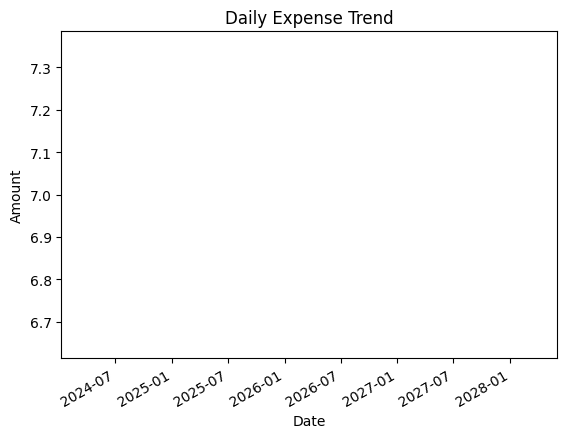

In [ ]:
import matplotlib.pyplot as plt

# Daily spending trend
df.groupby("date")["amount"].sum().plot()

plt.title("Daily Expense Trend")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.show()

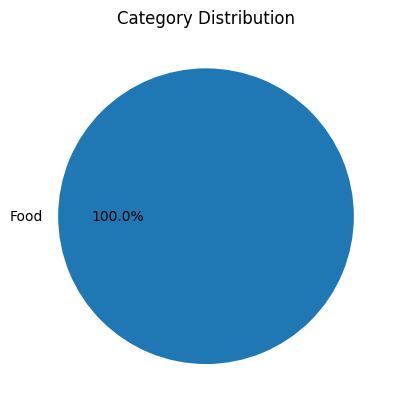

In [ ]:
category_spending.plot.pie(autopct="%1.1f%%")
plt.title("Category Distribution")
plt.ylabel("")
plt.show()

In [ ]:
def ai_advisor(df, income):
    total = df["amount"].sum()
    top_category = df.groupby("category")["amount"].sum().idxmax()

    if total > income:
        return "⚠️ You are overspending! Reduce unnecessary expenses."

    if top_category.lower() == "food":
        return "🍔 You spend a lot on food. Try cooking at home."

    if top_category.lower() == "shopping":
        return "🛍️ High shopping expenses detected. Control impulse buying."

    return "✅ Your finances look stable. Keep saving!"

# Run advisor
advice = ai_advisor(df, income)
print("\nAI Advice:\n", advice)


AI Advice:
 🍔 You spend a lot on food. Try cooking at home.


In [ ]:
print("\n===== FINAL FINANCIAL REPORT =====")

print("\nTop Spending Category:", category_spending.idxmax())
print("Total Expense:", total_expense)
print("Savings Rate:", savings_rate)

print("\nAI Suggestion:", advice)


===== FINAL FINANCIAL REPORT =====

Top Spending Category: Food
Total Expense: 7
Savings Rate: 99.92999999999999

AI Suggestion: 🍔 You spend a lot on food. Try cooking at home.
